In [1]:
import os
import glob
import tiktoken
import numpy as np
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import plotly.graph_objects as go

In [2]:
MODEL = "llama3.2:latest"
db_name = "vector_db"

load_dotenv(override=True)

# from .env
ollama_base_url = os.getenv("OLLAMA_BASE_URL")
hf_token = os.getenv("HF_TOKEN")

if ollama_base_url:
    print(f"Ollama base URL found: {ollama_base_url}")
else:
    print("OLLAMA_BASE_URL not set")

if hf_token:
    print(f"HF token exists and begins {hf_token[:8]}")
else:
    print("HF_TOKEN not set")

OLLAMA_BASE_URL not set
HF token exists and begins hf_jjPjQ


In [3]:
knowledge_base_path = "knowledge-base/**/*.md"
files = glob.glob(knowledge_base_path, recursive=True)
print(f"Found {len(files)} files in the knowledge base")

entire_knowledge_base = ""

for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as f:
        entire_knowledge_base += f.read()
        entire_knowledge_base += "\n\n"

print(f"Total characters in knowledge base: {len(entire_knowledge_base):,}")

Found 76 files in the knowledge base
Total characters in knowledge base: 304,434


In [4]:

encoding = tiktoken.get_encoding("cl100k_base")
tokens = encoding.encode(entire_knowledge_base)
token_count = len(tokens)
print(f"Total tokens (approx for {MODEL}): {token_count:,}")


Total tokens (approx for llama3.2:latest): 63,721


In [5]:
folders = glob.glob("knowledge-base/*")

documents = []
for folder in folders:
    doc_type = os.path.basename(folder)
    loader = DirectoryLoader(folder, glob="**/*.md", loader_cls=TextLoader, loader_kwargs={'encoding': 'utf-8'})
    folder_docs = loader.load()
    for doc in folder_docs:
        doc.metadata["doc_type"] = doc_type
        documents.append(doc)

print(f"Loaded {len(documents)} documents")
documents[1]

Loaded 76 documents


Document(metadata={'source': 'knowledge-base/products/Claimllm.md', 'doc_type': 'products'}, page_content="# Product Summary\n\n# Claimllm\n\n## Summary\n\nClaimllm is Insurellm's revolutionary claims processing platform that transforms the claims experience for insurers, adjusters, and policyholders. Powered by advanced AI, machine learning, and computer vision, Claimllm automates claims handling across all insurance lines—from first notice of loss through final settlement. By dramatically reducing processing time, improving accuracy, and enhancing fraud detection, Claimllm enables insurers to deliver exceptional claims service while significantly reducing operational costs. The platform seamlessly integrates with existing policy administration and core systems to create a unified insurance ecosystem.\n\n## Features\n\n### 1. Intelligent FNOL Processing\nClaimllm's AI-powered first notice of loss intake captures claim details through multiple channels including mobile apps, web portal

In [6]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents)

print(f"Divided into {len(chunks)} chunks")
print(f"First chunk:\n\n{chunks[0]}")


Divided into 413 chunks
First chunk:

page_content='# Product Summary

# Rellm: AI-Powered Enterprise Reinsurance Solution

## Summary

Rellm is an innovative enterprise reinsurance product developed by Insurellm, designed to transform the way reinsurance companies operate. Harnessing the power of artificial intelligence, Rellm offers an advanced platform that redefines risk management, enhances decision-making processes, and optimizes operational efficiencies within the reinsurance industry. With seamless integrations and robust analytics, Rellm enables insurers to proactively manage their portfolios and respond to market dynamics with agility.

## Features

### AI-Driven Analytics
Rellm utilizes cutting-edge AI algorithms to provide predictive insights into risk exposures, enabling users to forecast trends and make informed decisions. Its real-time data analysis empowers reinsurance professionals with actionable intelligence.' metadata={'source': 'knowledge-base/products/Rellm.md', '

In [15]:
#embeddings = HuggingFaceEmbeddings(
#    model_name="BAAI/bge-small-en-v1.5",
#    model_kwargs={"token": hf_token}
#)

embeddings = HuggingFaceEmbeddings(
     model_name="BAAI/bge-base-en-v1.5",
     model_kwargs={"token": hf_token}
)

# embeddings = HuggingFaceEmbeddings(
#     model_name="sentence-transformers/all-MiniLM-L6-v2",
#     model_kwargs={"token": hf_token}
# )



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:
if os.path.exists(db_name):
    Chroma(persist_directory=db_name, embedding_function=embeddings).delete_collection()

vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=db_name)
print(f"Vectorstore created with {vectorstore._collection.count()} documents")


Vectorstore created with 413 documents


In [17]:
collection = vectorstore._collection
count = collection.count()

sample_embedding = collection.get(limit=1, include=["embeddings"])["embeddings"][0]
dimensions = len(sample_embedding)
print(f"There are {count:,} vectors with {dimensions:,} dimensions in the vector store")

result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
metadatas = result['metadatas']

doc_types = [metadata['doc_type'] for metadata in metadatas]

There are 413 vectors with 768 dimensions in the vector store


/home/deepak/miniconda3/envs/llms/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


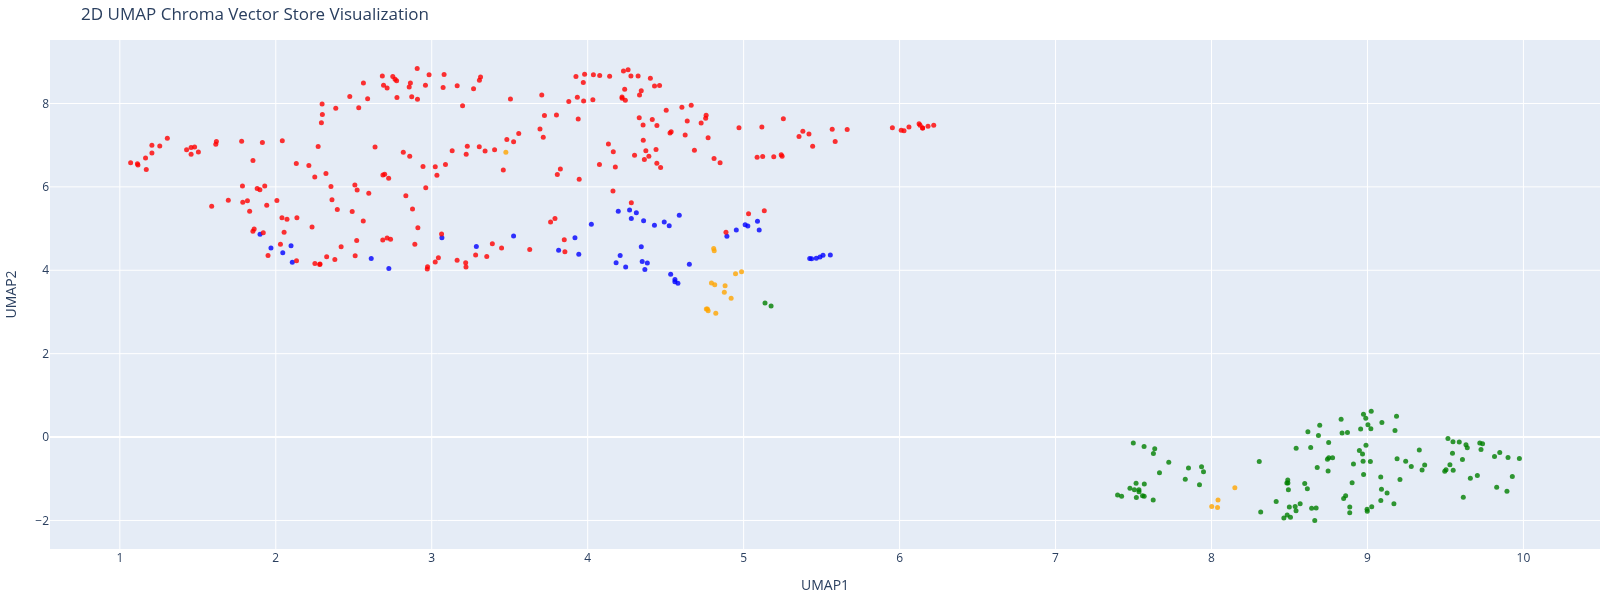

In [18]:
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

reduced_vectors = reducer.fit_transform(vectors)

fig = go.Figure(data=[go.Scatter(
    x=reduced_vectors[:, 0],
    y=reduced_vectors[:, 1],
    mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=[f"Type: {t}<br>Text: {d[:100]}..." for t, d in zip(doc_types, documents)],
    hoverinfo='text'
)])

fig.update_layout(
    title='2D UMAP Chroma Vector Store Visualization',
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40),
    xaxis_title='UMAP1',
    yaxis_title='UMAP2'
)

fig.show()